<a href="https://colab.research.google.com/github/ayushabhinandan-rath-dev/DataCleaning-Visualization/blob/main/DataCleaningVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [9]:
df = pd.read_csv('/content/clouds.csv')
df.head()

,Cloud Service,NVIDIA GPU,CPUs,GPU RAM,CPU RAM,Cost Per Hour,Wall Time,Cost to Train
0,Google Colab,K80,1,12.0,13,0.00,31.17,0.000
1,Google Cloud Compute Engine,P100,6,16.0,20,0.50,5.32,0.044
2,Google Cloud Compute Engine,K80,6,12.0,17,0.20,18.13,0.060
3,Google Cloud Compute Engine,V100,8,16.0,20,0.82,3.83,0.052
4,Google Cloud Compute Engine,P4,4,8.0,26,0.33,10.28,0.057


In [10]:
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Cloud Service  15 non-null     object 
 1   NVIDIA GPU     15 non-null     object 
 2   CPUs           15 non-null     int64  
 3   GPU RAM        15 non-null     float64
 4   CPU RAM        15 non-null     int64  
 5   Cost Per Hour  15 non-null     float64
 6   Wall Time      14 non-null     float64
 7   Cost to Train  15 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 1.1+ KB


Index(['Cloud Service', 'NVIDIA GPU', 'CPUs', 'GPU RAM ', 'CPU RAM ',
       'Cost Per Hour', 'Wall Time', 'Cost to Train'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
Cloud Service,0
NVIDIA GPU,0
CPUs,0
GPU RAM,0
CPU RAM,0
Cost Per Hour,0
Wall Time,1
Cost to Train,0


In [12]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Rows: 0


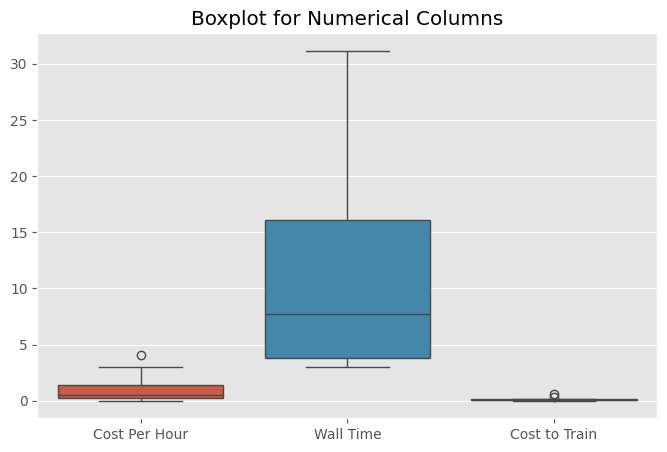

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Cost Per Hour','Wall Time','Cost to Train']])
plt.title("Boxplot for Numerical Columns")
plt.show()

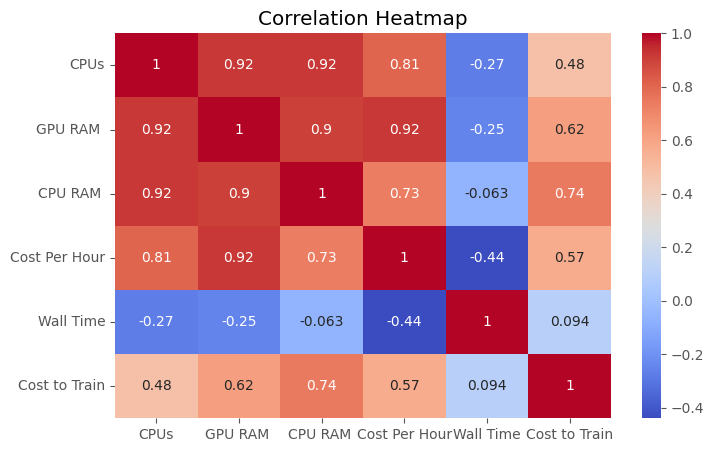

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

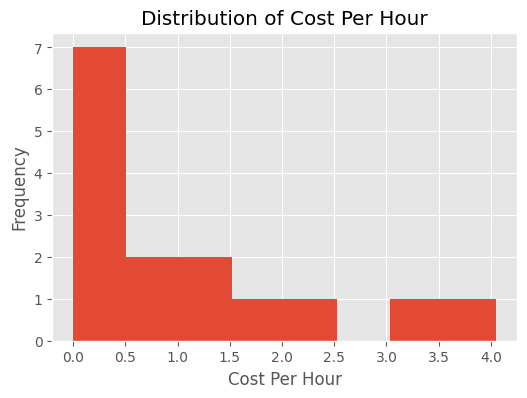

In [15]:
plt.figure(figsize=(6,4))

plt.hist(df["Cost Per Hour"], bins=8)

plt.title("Distribution of Cost Per Hour")
plt.xlabel("Cost Per Hour")
plt.ylabel("Frequency")

plt.show()

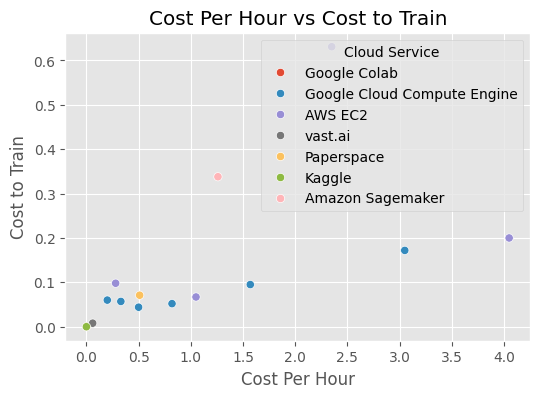

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,
                x="Cost Per Hour",
                y="Cost to Train",
                hue="Cloud Service")

plt.title("Cost Per Hour vs Cost to Train")

plt.show()

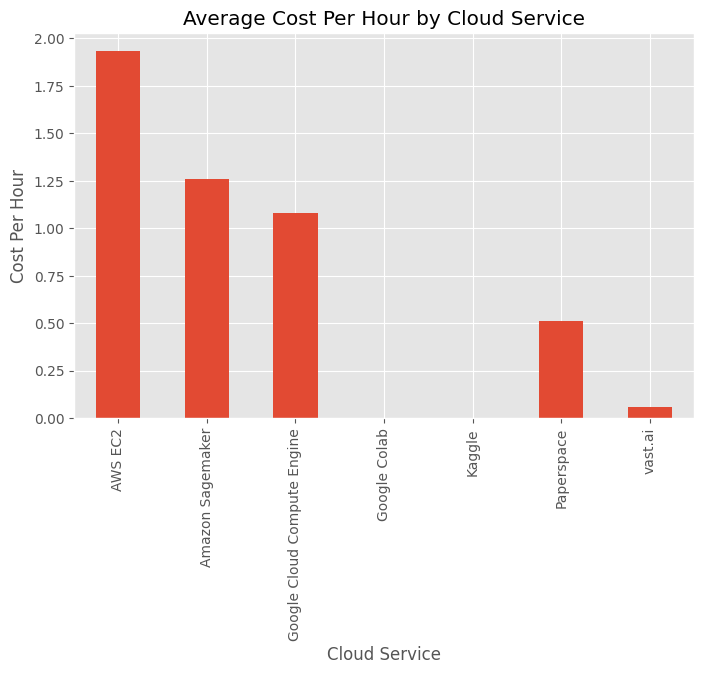

In [17]:
avg_cost = df.groupby("Cloud Service")["Cost Per Hour"].mean()

avg_cost.plot(kind='bar', figsize=(8,5))

plt.title("Average Cost Per Hour by Cloud Service")
plt.ylabel("Cost Per Hour")

plt.show()

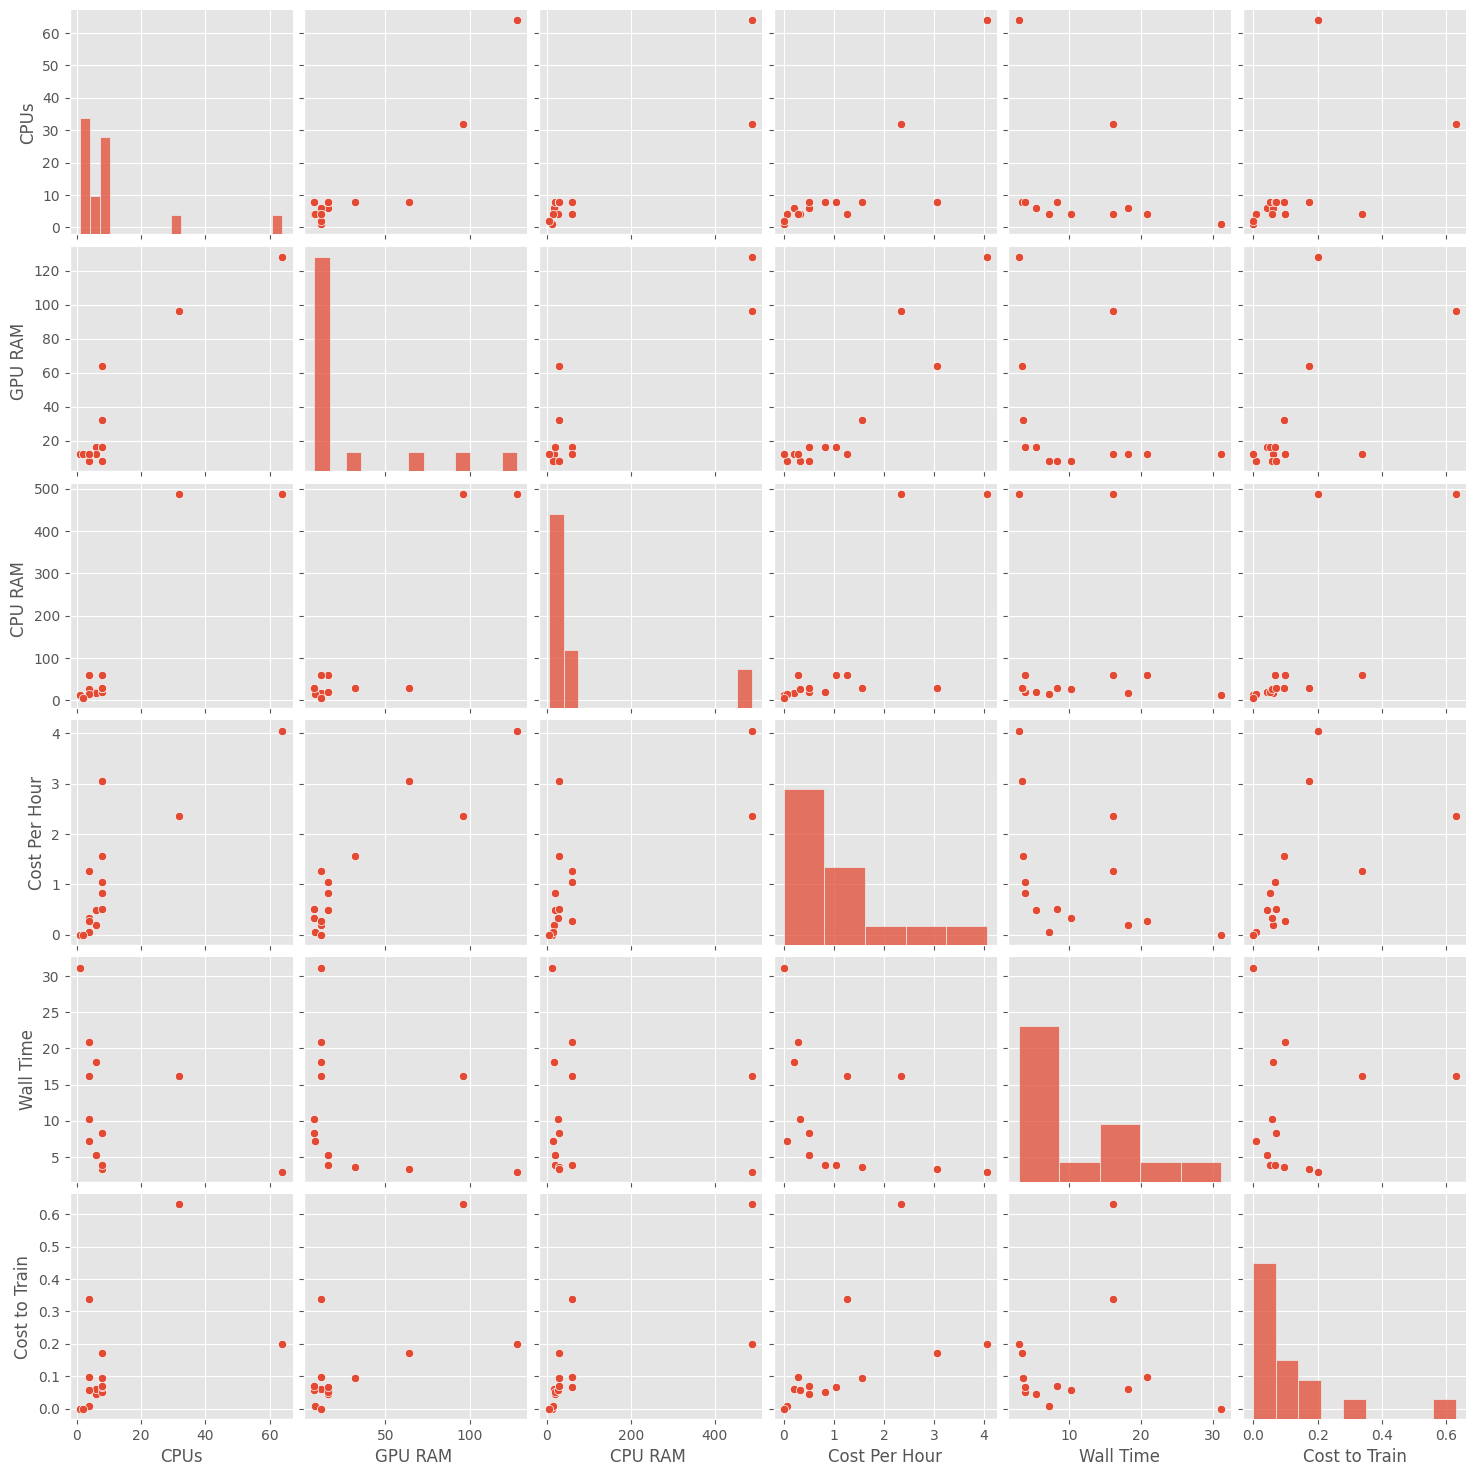

In [18]:
sns.pairplot(df)
plt.show()